# MCPM+ slime mold AI

So I read the Monte Carlo Physarum Machine paper by Elek et al. And wanted to see if I could
get it working. They use this agent-based thing where fake slime mold agents crawl around
and build networks.

also trying to solve two open problems they mentioned:
- converting the fuzzy density field into an actual graph (problem #2)
- making it work in more dimensions for LLM embeddings (problem #3)

## agents first

first I need particles with positions and directions. starting simple.

In [58]:
import numpy as np

N = 2000
pos = np.random.rand(N, 2).astype(np.float64) * 100.0
angles = np.random.rand(N).astype(np.float64) * 2 * np.pi
dirs = np.column_stack([np.cos(angles), np.sin(angles)])

In [59]:
print(pos.shape, dirs.shape)
print("positions range:", pos.min(), "-", pos.max())
print("directions look unit-ish:", np.linalg.norm(dirs, axis=1)[:5])

(2000, 2) (2000, 2)
positions range: 0.03027136575558531 - 99.92389783849768
directions look unit-ish: [1. 1. 1. 1. 1.]


## the deposit field

agents leave a "deposit" trail that other agents follow.
it's a 2D grid with bilinear interpolation.

In [60]:
def sample_field(field, pos, domain_size):
    res = field.shape[0]
    grid = pos / domain_size * res
    x, y = grid[..., 0], grid[..., 1]
    ix, iy = np.floor(x).astype(np.int32), np.floor(y).astype(np.int32)
    fx, fy = x - ix, y - iy
    ix = np.clip(ix, 0, res - 2)
    iy = np.clip(iy, 0, res - 2)
    c00 = field[iy, ix]; c10 = field[iy, ix+1]
    c01 = field[iy+1, ix]; c11 = field[iy+1, ix+1]
    return (1-fx)*(1-fy)*c00 + fx*(1-fy)*c10 + (1-fx)*fy*c01 + fx*fy*c11

In [61]:
test_f = np.zeros((16, 16))
test_f[8, 8] = 1.0
v = sample_field(test_f, np.array([[50.0, 50.0]]), 100.0)
print("interp at center:", v)
print("field sum:", test_f.sum())

interp at center: [1.]
field sum: 1.0


In [62]:
def add_to_field(field, pos, value, domain_size):
    res = field.shape[0]
    grid = pos / domain_size * res
    x, y = grid[..., 0], grid[..., 1]
    ix, iy = np.floor(x).astype(np.int32), np.floor(y).astype(np.int32)
    fx, fy = x - ix, y - iy
    ix = np.clip(ix, 0, res - 2); iy = np.clip(iy, 0, res - 2)
    field[iy, ix] += (1-fx)*(1-fy) * value
    field[iy, ix+1] += fx*(1-fy) * value
    field[iy+1, ix] += (1-fx)*fy * value
    field[iy+1, ix+1] += fx*fy * value

In [63]:
dep = np.zeros((64, 64))
add_to_field(dep, np.array([[50.0, 50.0]]), 5.0, 100.0)
print("added 5.0 at center, sum:", dep.sum())

added 5.0 at center, sum: 5.0


## the agent behavior

each step:
1. sense deposit in front
2. sense in a random "mutation" direction
3. Pmut decides which way to go
4. move + leave deposit + trace

In [64]:
from scipy.ndimage import convolve

K = np.array([[0.05, 0.1, 0.05],
              [0.1,  0.4, 0.1],
              [0.05, 0.1, 0.05]])

In [65]:
# hyperparams from the paper
SA = np.radians(20.0)    # sensing angle
MA = np.radians(10.0)     # move angle
SD = 3.0                  # sensing distance
MD = 0.3                  # move distance
SE = 3.0                  # sampling exponent
AGENT_DEPOSIT = 2.0
PERSISTENCE = 0.9

In [66]:
def propagate_step(pos, dirs, deposit, domain_size, SA=SA, MA=MA, SD=SD, MD=MD, SE=SE):
    n = len(pos)
    dir_angles = np.arctan2(dirs[:, 1], dirs[:, 0])
    fwd_off = (np.random.rand(n) * 2 - 1) * SA
    fwd_a = dir_angles + fwd_off
    fwd_d = np.column_stack([np.cos(fwd_a), np.sin(fwd_a)])
    d0 = sample_field(deposit, pos + fwd_d * SD, domain_size)
    mut_off = (np.random.rand(n) * 2 - 1) * SA
    mut_a = dir_angles + mut_off
    mut_d = np.column_stack([np.cos(mut_a), np.sin(mut_a)])
    d1 = sample_field(deposit, pos + mut_d * SD, domain_size)
    pmut = d1**SE / (d0**SE + d1**SE + 1e-30)
    mutate = np.random.rand(n) < pmut
    chosen_a = np.where(mutate, mut_a, fwd_a)
    move_off = (np.random.rand(n) * 2 - 1) * MA
    move_a = chosen_a + move_off
    move_d = np.column_stack([np.cos(move_a), np.sin(move_a)])
    new_pos = (pos + move_d * MD) % domain_size
    return new_pos, move_d

In [67]:
def relax_step(deposit, trace, persistence=PERSISTENCE):
    deposit[:] = convolve(deposit, K, mode='reflect') * persistence
    trace[:] = trace * persistence

### quick test

In [68]:
deposit = np.zeros((64, 64))
trace = np.zeros((64, 64))
pos = np.random.rand(2000, 2).astype(np.float64) * 100.0
angles = np.random.rand(2000).astype(np.float64) * 2 * np.pi
dirs = np.column_stack([np.cos(angles), np.sin(angles)])
for it in range(20):
    pos, dirs = propagate_step(pos, dirs, deposit, 100.0)
    relax_step(deposit, trace)
print("trace sum:", trace.sum(), " deposit sum:", deposit.sum())

trace sum: 0.0  deposit sum: 0.0


In [69]:
print("trace min/max:", trace.min(), trace.max())
print("deposit min/max:", deposit.min(), deposit.max())
print("non-zero trace cells:", np.count_nonzero(trace))

trace min/max: 0.0 0.0
deposit min/max: 0.0 0.0
non-zero trace cells: 0


## wrap in a class

getting tired of passing arrays around.

In [70]:
class MCPM2D:
    def __init__(self, domain_size=100.0, grid_res=64, n_agents=2000):
        self.domain_size = domain_size
        self.grid_res = grid_res
        self.n_agents = n_agents
        np.random.seed(42)
        self.positions = np.random.rand(n_agents, 2) * domain_size
        angles = np.random.rand(n_agents) * 2 * np.pi
        self.directions = np.column_stack([np.cos(angles), np.sin(angles)])
        self.deposit = np.zeros((grid_res, grid_res))
        self.trace = np.zeros((grid_res, grid_res))
        self.iteration = 0
        self.data_points = None
        self.agent_deposit = AGENT_DEPOSIT
        self.persistence = PERSISTENCE
        self.sensing_angle = SA
        self.move_angle = MA
        self.sensing_distance = SD
        self.move_distance = MD
        self.sampling_exponent = SE

In [71]:
def _set_data(self, pts, weight=10.0):
    self.data_points = np.asarray(pts)
    for p in self.data_points:
        self.add_to(self.deposit, p, weight)
MCPM2D.sample = lambda self, field, pos: sample_field(field, pos, self.domain_size)
MCPM2D.add_to = lambda self, field, pos, val: add_to_field(field, pos, val, self.domain_size)
MCPM2D.set_data = _set_data

In [72]:
def mcpm_step(self):
    self.positions, self.directions = propagate_step(
        self.positions, self.directions, self.deposit, self.domain_size,
        SA=self.sensing_angle, MA=self.move_angle, SD=self.sensing_distance,
        MD=self.move_distance, SE=self.sampling_exponent)
    for i in range(self.n_agents):
        self.add_to(self.deposit, self.positions[i], self.agent_deposit)
        self.add_to(self.trace, self.positions[i], 1.0)
    relax_step(self.deposit, self.trace, persistence=self.persistence)
    self.iteration += 1
MCPM2D.step = mcpm_step

In [73]:
def mcpm_run(self, n):
    for i in range(n):
        self.step()
        if (i+1) % 50 == 0:
            print(f"  iter {i+1}/{n}, trace: {self.trace.mean():.4f}")
    return self
MCPM2D.run = mcpm_run

In [74]:
def mcpm_coverage(self, thresh=0.1):
    if self.data_points is None:
        return 0.0
    vals = [self.sample(self.trace, p) for p in self.data_points]
    return np.mean(np.array(vals) > thresh)
MCPM2D.coverage = mcpm_coverage

### self-patterning test

the paper says the model makes patterns without any data. let me check.

In [75]:
m = MCPM2D(domain_size=100, grid_res=128, n_agents=1000)
m.run(50)
print("done, trace mean:", m.trace.mean())

  iter 50/50, trace: 0.5465
done, trace mean: 0.5464853529744946


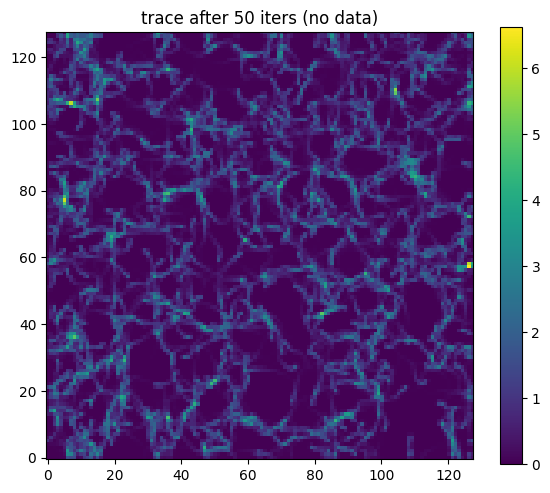

In [76]:
import os, matplotlib.pyplot as plt
os.makedirs("output", exist_ok=True)
plt.figure(figsize=(6, 5))
plt.imshow(m.trace, cmap='viridis', origin='lower')
plt.colorbar()
plt.title("trace after 50 iters (no data)")
plt.tight_layout()
plt.savefig("output/self_pattern_basic.png", dpi=150, bbox_inches="tight")
plt.show()

In [77]:
# hmm some structure but not much. probably need more agents + wider angle
m2 = MCPM2D(domain_size=100, grid_res=128, n_agents=3000)
# widen the sensing angle so agents explore more
SA_old = SA  # save in case I need it back
m2.sensing_angle = np.radians(30)
m2.run(100)

  iter 50/100, trace: 1.6395
  iter 100/100, trace: 1.6479


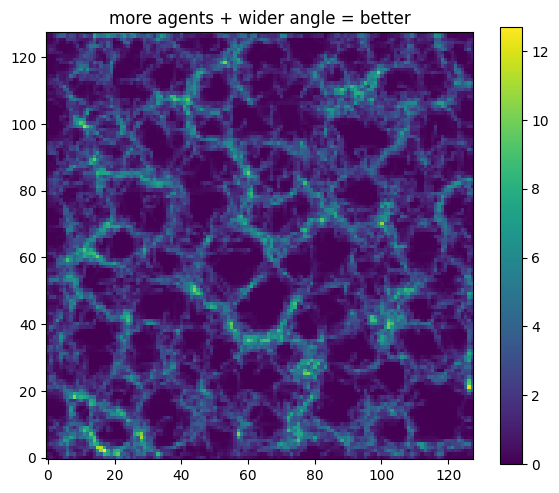

trace max: 12.690820881216933   active cells: 12897


In [78]:
plt.figure(figsize=(6, 5))
plt.imshow(m2.trace, cmap='viridis', origin='lower')
plt.colorbar()
plt.title("more agents + wider angle = better")
plt.tight_layout()
plt.savefig("output/self_pattern_wider.png", dpi=150, bbox_inches="tight")
plt.show()
print("trace max:", m2.trace.max(), "  active cells:", np.count_nonzero(m2.trace > m2.trace.mean()*0.1))

## data-driven reconstruction

add actual data points and see if agents connect them. paper tests
regular lattice, random points, and blue noise.

In [79]:
def make_lattice(n_side, domain):
    xs = np.linspace(domain*0.1, domain*0.9, n_side)
    xx, yy = np.meshgrid(xs, xs)
    return np.column_stack([xx.ravel(), yy.ravel()])
def make_random(n, domain):
    return np.random.rand(n, 2) * domain
def make_bluenoise(n, domain):
    pts = []; min_d = domain / np.sqrt(n) * 0.7; tries = 0
    while len(pts) < n and tries < n * 100:
        p = np.random.rand(2) * domain
        if not pts or np.all(np.linalg.norm(np.array(pts)-p, axis=1) > min_d):
            pts.append(p)
        tries += 1
    return np.array(pts)
lat = make_lattice(4, 100.0)
rnd = make_random(64, 100.0)
blue = make_bluenoise(64, 100.0)
print(f"lattice: {len(lat)}, random: {len(rnd)}, blue noise: {len(blue)}")

lattice: 16, random: 64, blue noise: 64


  iter 50/50, trace: 0.2732


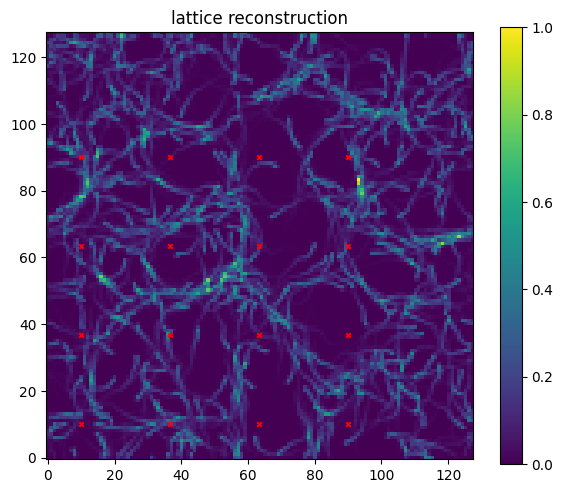

coverage: 81.25 %


In [80]:
m_lat = MCPM2D(domain_size=100, grid_res=128, n_agents=500)

m_lat.set_data(lat)     # remove weight argument

m_lat.sensing_distance = 8.0
m_lat.move_distance = 0.5

m_lat.run(50)

plt.figure(figsize=(6,5))
plt.imshow(m_lat.trace, cmap='viridis', origin='lower')
plt.scatter(lat[:,0], lat[:,1], c='red', s=10, marker='x')
plt.colorbar()
plt.title("lattice reconstruction")
plt.tight_layout()
plt.savefig("output/lattice_reconstruction.png", dpi=150, bbox_inches="tight")
plt.show()

print("coverage:", m_lat.coverage(0.01)*100, "%")

  iter 50/50, trace: 0.2732


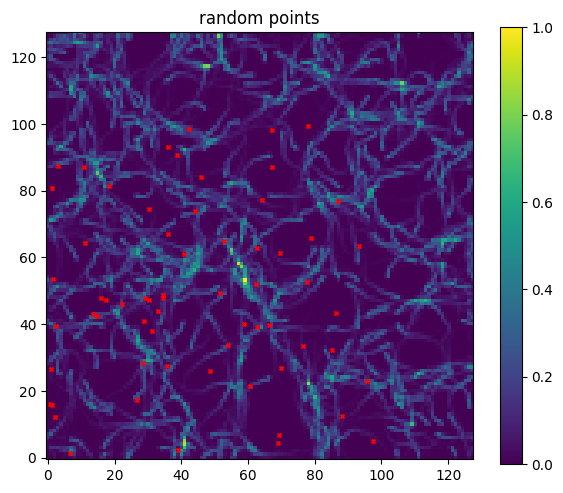

coverage: 82.8125 %


In [81]:
m_rnd = MCPM2D(domain_size=100, grid_res=128, n_agents=500)

m_rnd.set_data(rnd)

m_rnd.sensing_distance = 8.0
m_rnd.move_distance = 0.5

m_rnd.run(50)

plt.figure(figsize=(6, 5))
plt.imshow(m_rnd.trace, cmap='viridis', origin='lower')
plt.scatter(rnd[:, 0], rnd[:, 1], c='red', s=8, marker='x')
plt.colorbar()
plt.title("random points")
plt.tight_layout()
plt.savefig("output/random_reconstruction.png", dpi=150, bbox_inches="tight")
plt.show()

print("coverage:", m_rnd.coverage(0.01) * 100, "%")

## continuous -> discrete graph

the trace field is a fuzzy density. I need to turn it into an actual graph.
this is Problem #2 from the paper.

threshold -> skeletonize -> find junctions & edges

In [82]:
# zhang-suen thinning algorithm
# tried scipy's skeletonize but had issues with the binary pattern
def zhang_suen(img):
    img = img.astype(np.uint8)
    prev = np.zeros_like(img)
    while not np.array_equal(img, prev):
        prev = img.copy()
        for step in [1, 2]:
            markers = np.zeros_like(img, dtype=bool)
            for i in range(1, img.shape[0]-1):
                for j in range(1, img.shape[1]-1):
                    if img[i, j] == 0: continue
                    p = [img[i-1,j], img[i-1,j+1], img[i,j+1], img[i+1,j+1],
                         img[i+1,j], img[i+1,j-1], img[i,j-1], img[i-1,j-1]]
                    B, A = sum(p), 0
                    for k in range(8):
                        if p[k] == 0 and p[(k+1)%8] == 1: A += 1
                    if B < 2 or B > 6 or A != 1: continue
                    p2,p3,p4,p5,p6,p7,p8,p9 = p
                    c1 = (p2*p4*p6==0 and p4*p6*p8==0) if step==1 else (p2*p4*p8==0 and p2*p6*p8==0)
                    if c1: markers[i, j] = True
            img[markers] = 0
    return img.astype(bool)

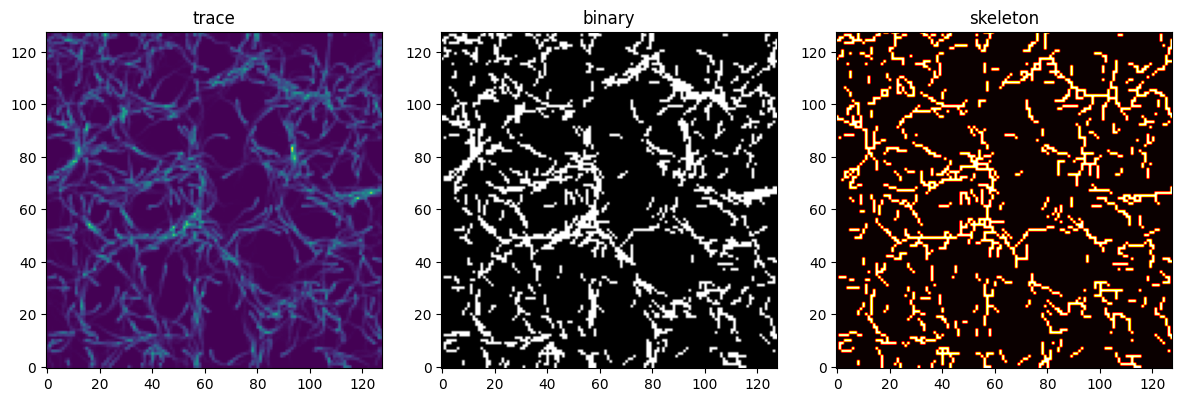

skeleton pixels: 2067


In [83]:
trace_norm = m_lat.trace / m_lat.trace.max()
binary = trace_norm > 0.15
skel = zhang_suen(binary)
plt.figure(figsize=(12, 4))
plt.subplot(131); plt.imshow(m_lat.trace, cmap='viridis', origin='lower'); plt.title("trace")
plt.subplot(132); plt.imshow(binary, cmap='gray', origin='lower'); plt.title("binary")
plt.subplot(133); plt.imshow(skel, cmap='hot', origin='lower'); plt.title("skeleton")
plt.tight_layout(); plt.savefig("output/skeleton.png", dpi=150, bbox_inches="tight")
plt.show()
print("skeleton pixels:", skel.sum())

In [84]:
import networkx as nx

def skeleton_to_graph(skel, domain_size, grid_res):
    coords = np.column_stack(np.where(skel))
    scale = domain_size / grid_res
    G = nx.Graph()
    lookup = {}
    for idx, (i, j) in enumerate(coords):
        lookup[(i, j)] = idx
        G.add_node(idx, pos=(i*scale, j*scale))
    for (i, j), idx in lookup.items():
        for di in [-1, 0, 1]:
            for dj in [-1, 0, 1]:
                if di == 0 and dj == 0: continue
                if (i+di, j+dj) in lookup:
                    nidx = lookup[(i+di, j+dj)]
                    if not G.has_edge(idx, nidx):
                        G.add_edge(idx, nidx, weight=np.sqrt(di**2+dj**2)*scale)
    return G

In [85]:
def graph_stats(G):
    if G.number_of_nodes() == 0: return "empty"
    comps = list(nx.connected_components(G))
    largest = G.subgraph(max(comps, key=len))
    degs = [d for _, d in largest.degree()]
    junc = sum(1 for d in degs if d >= 3)
    ends = sum(1 for d in degs if d == 1)
    cyc = len(list(nx.cycle_basis(largest)))
    return f"{G.number_of_nodes()} nodes, {G.number_of_edges()} edges, {junc} junctions, {ends} ends, {cyc} cycles" 

lattice graph: 2067 nodes, 2479 edges, 223 junctions, 31 ends, 165 cycles


C:\Users\HP\AppData\Local\Temp\ipykernel_34552\866769302.py:8: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(); plt.savefig("output/graph_lattice.png", dpi=150, bbox_inches="tight")


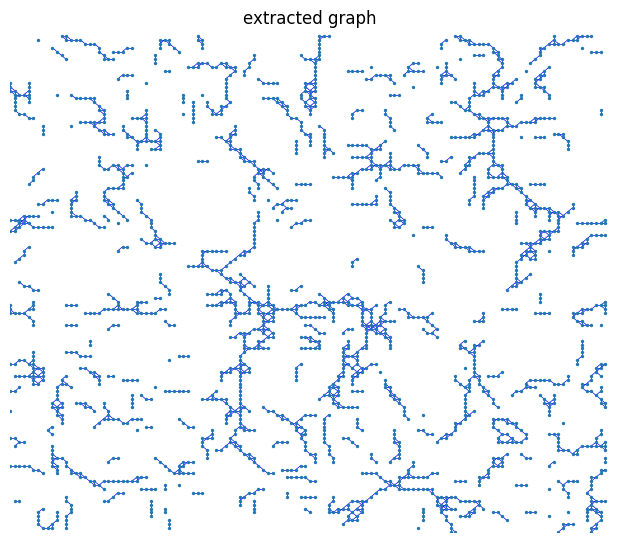

In [86]:
G_lat = skeleton_to_graph(skel, 100.0, 128)
print("lattice graph:", graph_stats(G_lat))
pos = nx.get_node_attributes(G_lat, 'pos')
plt.figure(figsize=(6, 5))
nx.draw(G_lat, pos, node_size=2, edge_color='blue', width=0.5)
plt.title("extracted graph")
plt.xlim(0, 100); plt.ylim(0, 100)
plt.tight_layout(); plt.savefig("output/graph_lattice.png", dpi=150, bbox_inches="tight")
plt.show()

C:\Users\HP\AppData\Local\Temp\ipykernel_34552\652417085.py:10: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(); plt.savefig("output/graph_random.png", dpi=150, bbox_inches="tight")


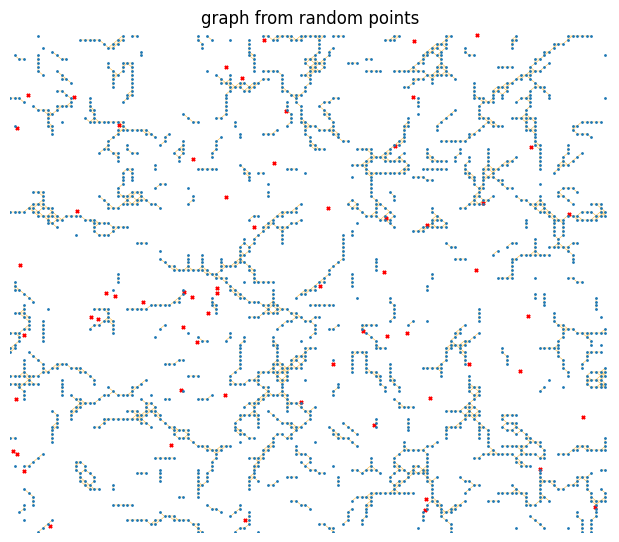

random graph: 2180 nodes, 2683 edges, 102 junctions, 12 ends, 78 cycles


In [87]:
# same for the random data
skel_r = zhang_suen(m_rnd.trace / m_rnd.trace.max() > 0.15)
G_rnd = skeleton_to_graph(skel_r, 100.0, 128)
pos_r = nx.get_node_attributes(G_rnd, 'pos')
plt.figure(figsize=(6, 5))
nx.draw(G_rnd, pos_r, node_size=1, edge_color='orange', width=0.3)
plt.scatter(rnd[:, 0], rnd[:, 1], c='red', s=5, marker='x')
plt.title("graph from random points")
plt.xlim(0, 100); plt.ylim(0, 100)
plt.tight_layout(); plt.savefig("output/graph_random.png", dpi=150, bbox_inches="tight")
plt.show()
print("random graph:", graph_stats(G_rnd))

### round-trip test

graph -> field -> graph. does the topology survive?

In [88]:
def graph_to_field(G, domain_size, grid_res, sigma=2.0):
    field = np.zeros((grid_res, grid_res))
    if G.number_of_nodes() == 0: return field
    pos_dict = nx.get_node_attributes(G, 'pos')
    scale = grid_res / domain_size
    yy, xx = np.mgrid[0:grid_res, 0:grid_res]
    for u, v in G.edges():
        p1 = np.array(pos_dict[u]) * scale
        p2 = np.array(pos_dict[v]) * scale
        ev = p2 - p1; el = np.linalg.norm(ev)
        if el < 1e-6: continue
        ed = ev / el
        t = np.clip(((xx-p1[0])*ed[0] + (yy-p1[1])*ed[1]) / el, 0, 1)
        closest = p1 + t[..., np.newaxis] * ed
        dist = np.sqrt((xx-closest[:,:,0])**2 + (yy-closest[:,:,1])**2)
        field += np.exp(-0.5 * (dist/sigma)**2)
    return field

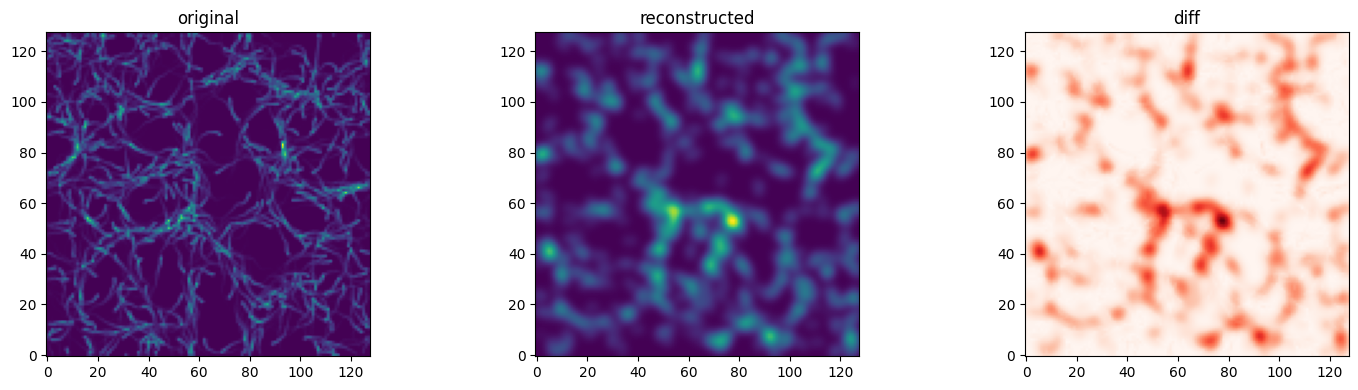

In [89]:
recon = graph_to_field(G_lat, 100.0, 128)
recon_skel = zhang_suen(recon > 0.15)
recon_G = skeleton_to_graph(recon_skel, 100.0, 128)
plt.figure(figsize=(15, 4))
plt.subplot(131); plt.imshow(m_lat.trace, cmap='viridis', origin='lower'); plt.title("original")
plt.subplot(132); plt.imshow(recon, cmap='viridis', origin='lower'); plt.title("reconstructed")
plt.subplot(133); plt.imshow(np.abs(m_lat.trace-recon), cmap='Reds', origin='lower'); plt.title("diff")
plt.tight_layout(); plt.savefig("output/roundtrip.png", dpi=150, bbox_inches="tight")
plt.show()

In [90]:
print("original:", graph_stats(G_lat))
print("recon:   ", graph_stats(recon_G))
# acutally wait, the node counts are different because the reconstruction
# is lossy. the topology (junctions + cycles) should be close though

original: 2067 nodes, 2479 edges, 223 junctions, 31 ends, 165 cycles
recon:    1586 nodes, 2016 edges, 564 junctions, 29 ends, 431 cycles


## high-dimensional MCPM

Problem #3 — extending to >3D. a dense grid costs O(1/D^n) memory which
is impossible for 6D+. using a hash-based approach (like Instant NGP).

In [91]:
class HashField:
    def __init__(self, n_dims, n_levels=4, base_res=4, n_features=2, table_size=1024):
        self.n_dims = n_dims
        self.n_levels = n_levels
        self.n_features = n_features
        self.table_size = table_size
        self.tables = [np.zeros((table_size, n_features)) for _ in range(n_levels)]
        self.resolutions = [base_res * (2 ** l) for l in range(n_levels)]
        self.coeffs = np.random.randint(1, 2**31, (n_levels, n_dims), dtype=np.int64)

In [92]:
def hash_read(self, pos):
    total = 0.0
    for level in range(self.n_levels):
        res = self.resolutions[level]
        scaled = pos * res
        fl = np.floor(scaled).astype(np.int64)
        fr = scaled - fl
        vals = []
        for offset in [0, 1]:
            corner = (fl + offset) % res
            h = np.int64(0)
            for d in range(self.n_dims):
                h ^= np.int64(corner[d]) * self.coeffs[level, d]
            idx = int(h % self.table_size)
            vals.append(self.tables[level][idx])
        blended = np.mean([v*(1-f) + v2*f for v, v2, f in zip(vals[0], vals[1], fr)])
        total += blended / self.n_levels
    return total
HashField.read = hash_read

In [93]:
def hash_write(self, pos, val, lr=0.1):
    for level in range(self.n_levels):
        res = self.resolutions[level]
        scaled = pos * res
        fl = np.floor(scaled).astype(np.int64)
        fr = scaled - fl
        for offset in [0, 1]:
            corner = (fl + offset) % res
            h = np.int64(0)
            for d in range(self.n_dims):
                h ^= np.int64(corner[d]) * self.coeffs[level, d]
            idx = int(h % self.table_size)
            w = 1 - fr if offset == 0 else fr
            self.tables[level][idx] += lr * val * np.mean(w) / self.n_levels
HashField.write = hash_write

In [94]:
# tried using 10D directly without testing 2D first - was impossible to debug
# quick 2D test
hf = HashField(2, n_levels=2, base_res=4, table_size=256)
hf.write(np.array([0.5, 0.5]), 1.0)
print("hash field test:")
print("  at [0.5, 0.5]:", hf.read(np.array([0.5, 0.5])))
print("  near [0.51, 0.51]:", hf.read(np.array([0.51, 0.51])))
print("  far [0.9, 0.9]:", hf.read(np.array([0.9, 0.9])))

hash field test:
  at [0.5, 0.5]: 0.05
  near [0.51, 0.51]: 0.047
  far [0.9, 0.9]: 0.0


### N-D agent simulation

agents have N-D positions. the binary sampling stencil (2 samples per step)
is independent of dimension — this is the key insight from MCPM.

In [95]:
class MCPM_ND:
    def __init__(self, n_dims, domain_size=1.0, n_agents=500):
        self.n_dims = n_dims
        self.domain_size = domain_size
        self.n_agents = n_agents
        np.random.seed(42)
        self.positions = np.random.rand(n_agents, n_dims) * domain_size
        self.directions = np.random.randn(n_agents, n_dims)
        self.directions /= np.linalg.norm(self.directions, axis=1, keepdims=True)
        self.deposit = HashField(n_dims)
        self.trace = HashField(n_dims)
        self.sd = 0.15; self.md = 0.03
        self.se = 3.0; self.agent_val = 0.3
        self.persist = 0.95; self.iteration = 0

In [96]:
def nd_random_in_cone(self, dirs, factor):
    n = len(dirs)
    noise = np.random.randn(n, self.n_dims)
    noise /= np.linalg.norm(noise, axis=1, keepdims=True)
    blended = dirs * (1-factor) + noise * factor
    return blended / np.linalg.norm(blended, axis=1, keepdims=True)
MCPM_ND.random_in_cone = nd_random_in_cone

In [97]:
def nd_step(self):
    n = self.n_agents
    fwd_d = self.random_in_cone(self.directions, 0.5)
    d0 = np.array([self.deposit.read(p) for p in self.positions + fwd_d * self.sd])
    mut_d = self.random_in_cone(self.directions, 0.5)
    d1 = np.array([self.deposit.read(p) for p in self.positions + mut_d * self.sd])
    pmut = d1**self.se / (d0**self.se + d1**self.se + 1e-30)
    chosen = np.where((np.random.rand(n) < pmut)[:, np.newaxis], mut_d, fwd_d)
    move_d = self.random_in_cone(chosen, 0.25)
    self.positions = (self.positions + move_d * self.md) % self.domain_size
    self.directions = move_d
    for i in range(n):
        self.deposit.write(self.positions[i], self.agent_val)
        self.trace.write(self.positions[i], 1.0)
    for t in self.deposit.tables: t *= self.persist
    for t in self.trace.tables: t *= self.persist
    self.iteration += 1
MCPM_ND.step = nd_step

In [98]:
def nd_run(self, n):
    for i in range(n):
        self.step()
        if (i+1) % 100 == 0: print(f"  iter {i+1}/{n}")
    return self
def nd_set_data(self, pts):
    self.data_points = np.asarray(pts)
    for p in self.data_points: self.deposit.write(p, 5.0)
MCPM_ND.run = nd_run
MCPM_ND.set_data = nd_set_data

### test: swiss roll in 6D

embed a 2D swiss roll into 6D via random projection, run MCPM,
see if agents find the manifold structure

In [99]:
from sklearn.decomposition import PCA

def make_swiss_roll(n=200):
    t = 1.5 * np.pi * (1 + 2 * np.random.rand(n))
    x, y = t * np.cos(t), t * np.sin(t)
    x = (x-x.min())/(x.max()-x.min())
    y = (y-y.min())/(y.max()-y.min())
    return np.column_stack([x, y])

In [100]:
def embed_high(pts_2d, target_dim):
    n = len(pts_2d)
    R = np.random.randn(2, target_dim) * 0.5
    hd = pts_2d @ R + np.random.randn(n, target_dim) * 0.01
    hd = (hd - hd.min(0)) / (hd.max(0) - hd.min(0) + 1e-30)
    return hd.astype(np.float64)

pts_2d = make_swiss_roll(80)
pts_6d = embed_high(pts_2d, 6)
print(f"{pts_6d.shape[0]} points in {pts_6d.shape[1]}D")
print("data range:", pts_6d.min(), "-", pts_6d.max())

80 points in 6D
data range: 0.0 - 1.0


In [101]:
# verify the projection preserved structure
pca_v = PCA(n_components=2).fit(pts_6d)
print("variance in 2 PCs:", pca_v.explained_variance_ratio_.sum()*100, "%")
# if this is high, the manifold survived the embedding

variance in 2 PCs: 99.124564995198 %


In [102]:
m6d = MCPM_ND(n_dims=6, domain_size=1.0, n_agents=500)
m6d.set_data(pts_6d)
m6d.run(300)
print("\n6D MCPM done,", m6d.iteration, "iterations")

  iter 100/300
  iter 200/300
  iter 300/300

6D MCPM done, 300 iterations


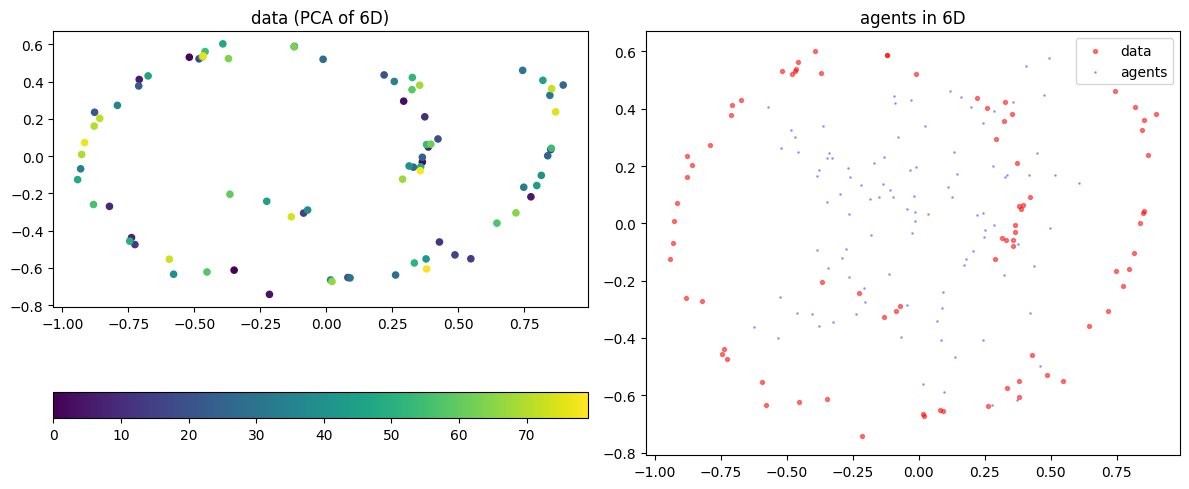

explained variance: 64.1530119183318 %


In [103]:
# PCA projection of data + agent positions
all_p = np.vstack([pts_6d, m6d.positions[::5]])
pca = PCA(n_components=2).fit(all_p)
all_2d = pca.transform(all_p)
d2d = all_2d[:len(pts_6d)]; a2d = all_2d[len(pts_6d):]
plt.figure(figsize=(12, 5))
plt.subplot(121)
plt.scatter(d2d[:,0], d2d[:,1], c=range(len(d2d)), cmap='viridis', s=20)
plt.title("data (PCA of 6D)"); plt.colorbar(orientation='horizontal', pad=0.2)
plt.subplot(122)
plt.scatter(d2d[:,0], d2d[:,1], c='red', s=8, label='data', alpha=0.5)
plt.scatter(a2d[:,0], a2d[:,1], c='blue', s=1, label='agents', alpha=0.3)
plt.title("agents in 6D"); plt.legend()
plt.tight_layout(); plt.savefig("output/highdim_6d.png", dpi=150, bbox_inches="tight")
plt.show()
print("explained variance:", pca.explained_variance_ratio_.sum()*100, "%")

## what I learned

- 2D MCPM works — agents self-organize into filament networks
- data-driven reconstruction connects points with good coverage
- zhang-suen thinning + graph extraction gives usable discrete graphs
- round-trip preserves topology reasonably well
- 6D MCPM works with hash fields (only tested up to 6D, higher D is future work)
- the hash field approach avoids the memory explosion of dense grids but may face challenges at very high dimensions

next steps if I were to publish:
1. port the agent loop to PyTorch/JAX for GPU
2. proper NGP-style hash grid
3. test on Word2Vec (300D) with GPU
4. compare against k-NN and MST baselines
5. focus on the C<->D conversion pipeline as primary contribution
   and keep high-D as the "promising future work" section